# Library

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score, classification_report
import random
import math
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
import statsmodels.api as sm

SEED = 1

random.seed(SEED)
np.random.seed(SEED)

# Load Data

In [51]:
var_y = pd.read_csv('var_y.csv')
df = pd.read_csv('df.csv')

In [52]:
var_y.head()

,Y1,Y2,Y3,Y4,Y5,Y6,Y7,Y8,Y9,Y10,Y11,Y12,Y13,Y14,Y15,Y16,Y17,Y18,Y19,Y20
0,2,5,5,5,4,5,5,5,5,3,3,2,5,4,4,2,5,4,3,5
1,2,2,4,3,4,2,4,4,4,3,4,4,4,2,2,2,5,4,5,5
2,3,2,5,4,2,3,4,5,3,3,4,4,4,3,3,2,3,3,3,2
3,2,3,4,4,3,3,4,2,2,3,5,4,3,4,4,2,3,3,4,3
4,1,1,2,3,3,3,4,3,3,4,2,2,2,3,3,2,1,4,4,1


In [53]:
df.head()

,Kelas,Gender,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10
0,LC09,Pria,3,3,2,2,3,3,2,3,2,2
1,LA09,Wanita,3,2,2,2,2,3,2,2,2,2
2,LB09,Pria,4,3,3,2,2,4,3,3,3,2
3,LB09,Pria,3,3,3,2,3,4,3,4,3,4
4,LB09,Wanita,3,3,2,2,3,3,3,3,3,3


# Analysis

Populasi Total B28 Data Science Kemanggisan (Lokasi: G. Anggrek): 167 mahasiswa

Populasi tiap Kelas (strata):
- LA09: 34 mahasiswa
- LB09: 35 mahasiswa
- LC09: 32 mahasiswa
- LD09: 32 mahasiswa
- LE09: 34 mahasiswa

Weight Per Kelas Lab (sebelum data collection):
- 0.20
- 0.21
- 0.19
- 0.19
- 0.20

Revisi Perhitungan Awal
$$n_0 = \frac{Z^2 \cdot p(1-p)}{e^2}$$

$$ = \frac{(1.96)^2 \times 0.5 \times 0.5}{(0.10)^2} = \frac{3.8416 \times 0.25}{0.01} = \frac{0.9604}{0.01} = 96.04$$

Menyesuaikan dengan Jumlah Populasi Angkatan
$$n = \frac{n_0}{1 + \dfrac{n_0 - 1}{N}}$$

$$ = \frac{96.04}{1 + \dfrac{95.04}{167}} = \frac{96.04}{1.5691} = 61.2 \approx \textbf{62 responden}$$

Weighting per kelas
$$n_h = \frac{N_h}{N} \times n = \frac{N_h}{167} \times 62$$

In [54]:
sample_needed = {}

populasi = {
    'LA09': 34, 'LB09': 35, 'LC09': 32,
    'LD09': 32, 'LE09': 34
}

for name, val in populasi.items():
    sample_needed[name] = math.ceil(val / 167 * 62)

print(sample_needed)

{'LA09': 13, 'LB09': 13, 'LC09': 12, 'LD09': 12, 'LE09': 13}


In [55]:
sample_get = df['Kelas'].value_counts().sort_index().to_dict()
print(sample_get)

{'LA09': 14, 'LB09': 21, 'LC09': 12, 'LD09': 4, 'LE09': 7}


$$w_h = \frac{P_h}{f_h} = \frac{N_h/N}{n_h/n} = \frac{N_h}{N} \times \frac{n}{n_h}$$

In [56]:
weight = {}

n = sum(sample_get.values())

for kelas in populasi:
    weight[kelas] = round((populasi[kelas] / 167) / (sample_get[kelas] / n), 4)
    
print(weight)

{'LA09': 0.8435, 'LB09': 0.5788, 'LC09': 0.9261, 'LD09': 2.7784, 'LE09': 1.6869}


In [57]:
print(var_y.shape)
var_y.info()

(58, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58 entries, 0 to 57
Data columns (total 20 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Y1      58 non-null     int64
 1   Y2      58 non-null     int64
 2   Y3      58 non-null     int64
 3   Y4      58 non-null     int64
 4   Y5      58 non-null     int64
 5   Y6      58 non-null     int64
 6   Y7      58 non-null     int64
 7   Y8      58 non-null     int64
 8   Y9      58 non-null     int64
 9   Y10     58 non-null     int64
 10  Y11     58 non-null     int64
 11  Y12     58 non-null     int64
 12  Y13     58 non-null     int64
 13  Y14     58 non-null     int64
 14  Y15     58 non-null     int64
 15  Y16     58 non-null     int64
 16  Y17     58 non-null     int64
 17  Y18     58 non-null     int64
 18  Y19     58 non-null     int64
 19  Y20     58 non-null     int64
dtypes: int64(20)
memory usage: 9.2 KB


In [58]:
print(df.shape)
df.info()

(58, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58 entries, 0 to 57
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Kelas   58 non-null     object
 1   Gender  58 non-null     object
 2   X1      58 non-null     int64 
 3   X2      58 non-null     int64 
 4   X3      58 non-null     int64 
 5   X4      58 non-null     int64 
 6   X5      58 non-null     int64 
 7   X6      58 non-null     int64 
 8   X7      58 non-null     int64 
 9   X8      58 non-null     int64 
 10  X9      58 non-null     int64 
 11  X10     58 non-null     int64 
dtypes: int64(10), object(2)
memory usage: 5.6+ KB


In [59]:
df[['Kelas', 'Gender']].value_counts().sort_index()

Kelas  Gender
LA09   Pria       8
       Wanita     6
LB09   Pria      14
       Wanita     7
LC09   Pria      10
       Wanita     2
LD09   Pria       3
       Wanita     1
LE09   Pria       6
       Wanita     1
Name: count, dtype: int64

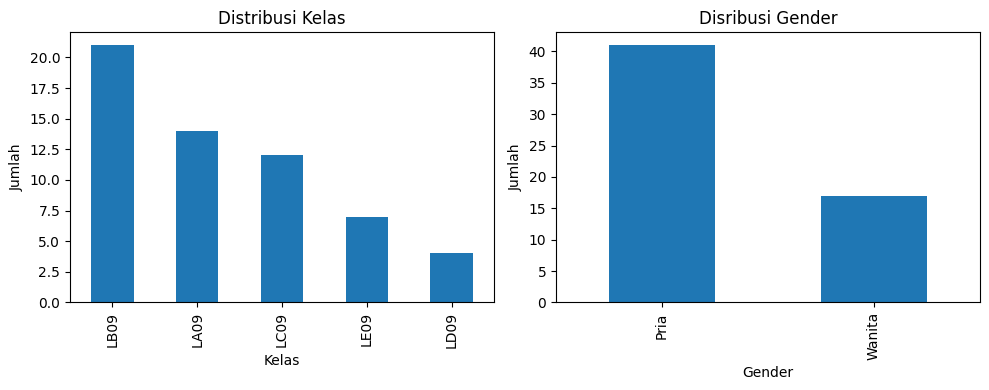

In [60]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

df['Kelas'].value_counts().plot(kind = 'bar', ax = ax[0])
ax[0].set_title('Distribusi Kelas')
ax[0].set_xlabel('Kelas')
ax[0].set_ylabel('Jumlah')

df['Gender'].value_counts().plot(kind = 'bar', ax = ax[1])
ax[1].set_xlabel('Gender')
ax[1].set_title('Disribusi Gender')
ax[1].set_ylabel('Jumlah')

plt.tight_layout()
plt.show()

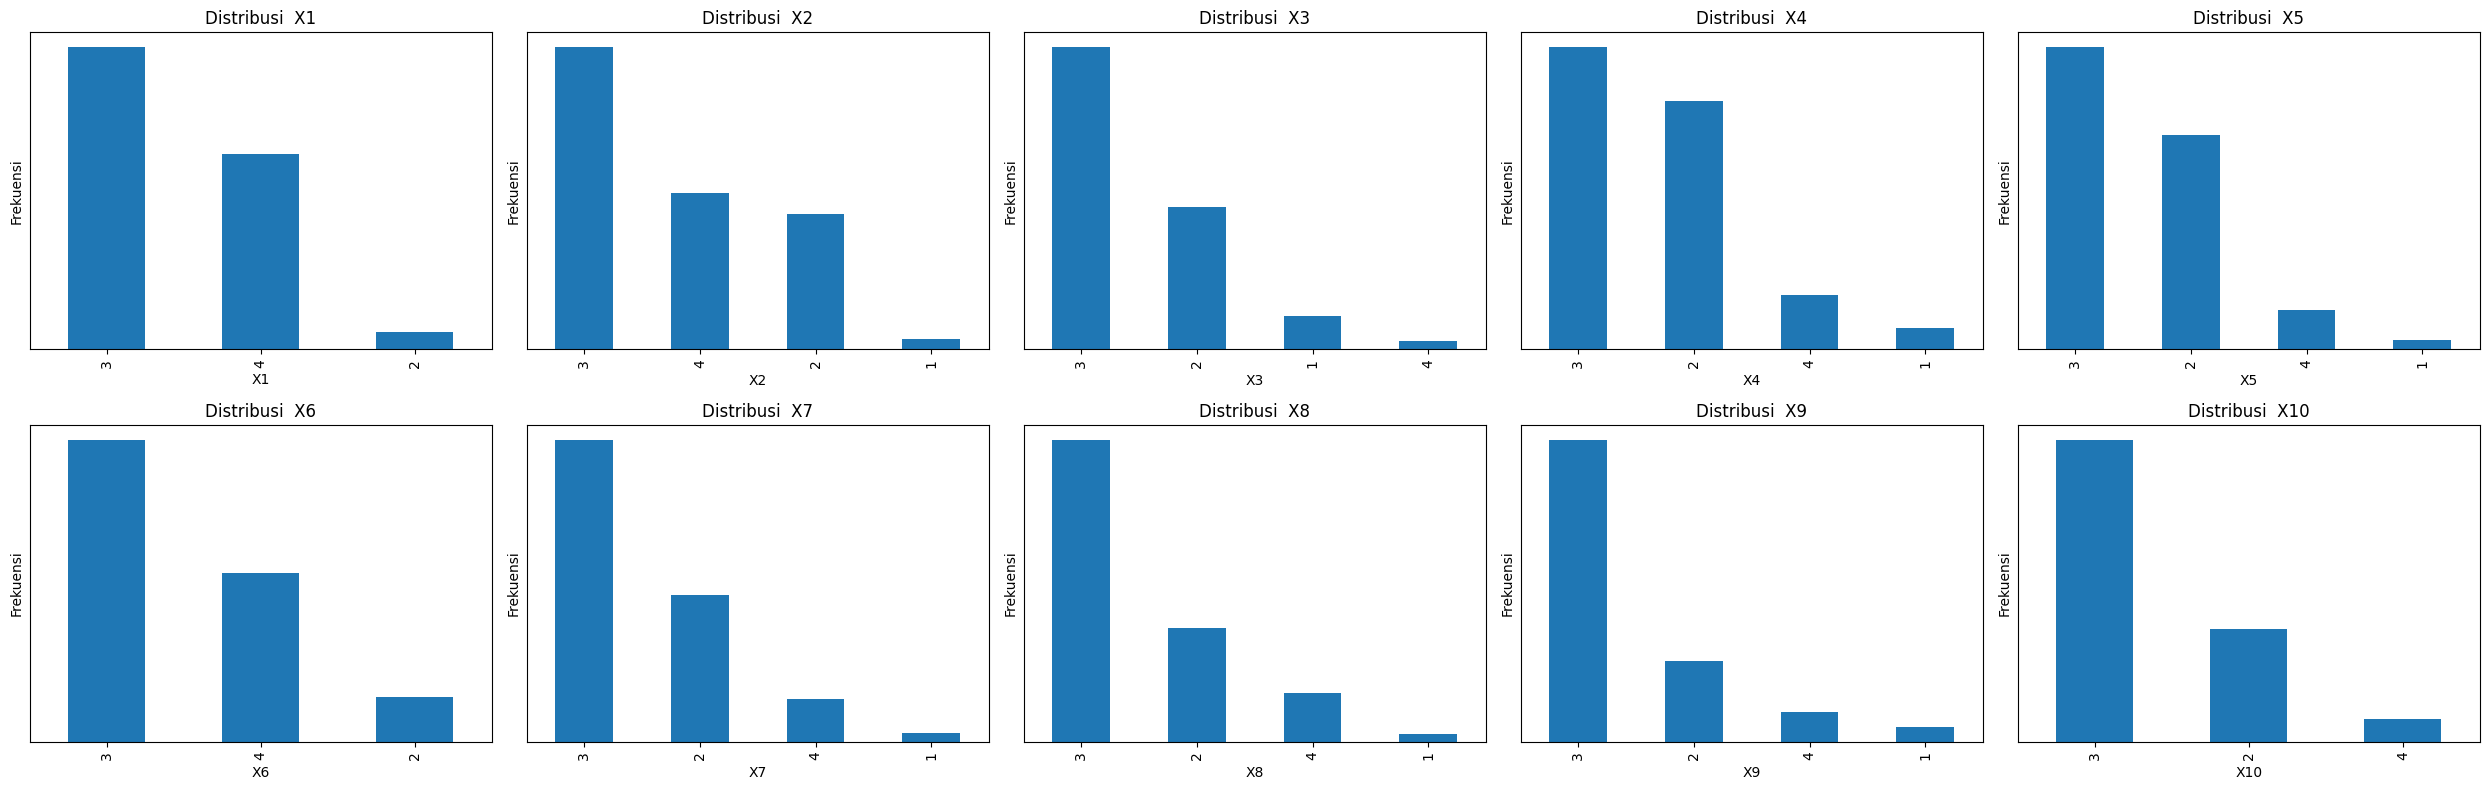

In [61]:
var_x = df.iloc[:, 2:]

fig, ax = plt.subplots(2, 5, figsize=(25, 8))

ax = ax.flatten()

for i, col in enumerate(var_x.columns):
    var_x[col].value_counts().plot(kind = 'bar', ax = ax[i])
    ax[i].set_title(f'Distribusi  {col}')
    ax[i].set_xlabel(f'{col}')
    ax[i].set_ylabel('Frekuensi')
    ax[i].set_yticks([])
    
plt.tight_layout()
plt.show()

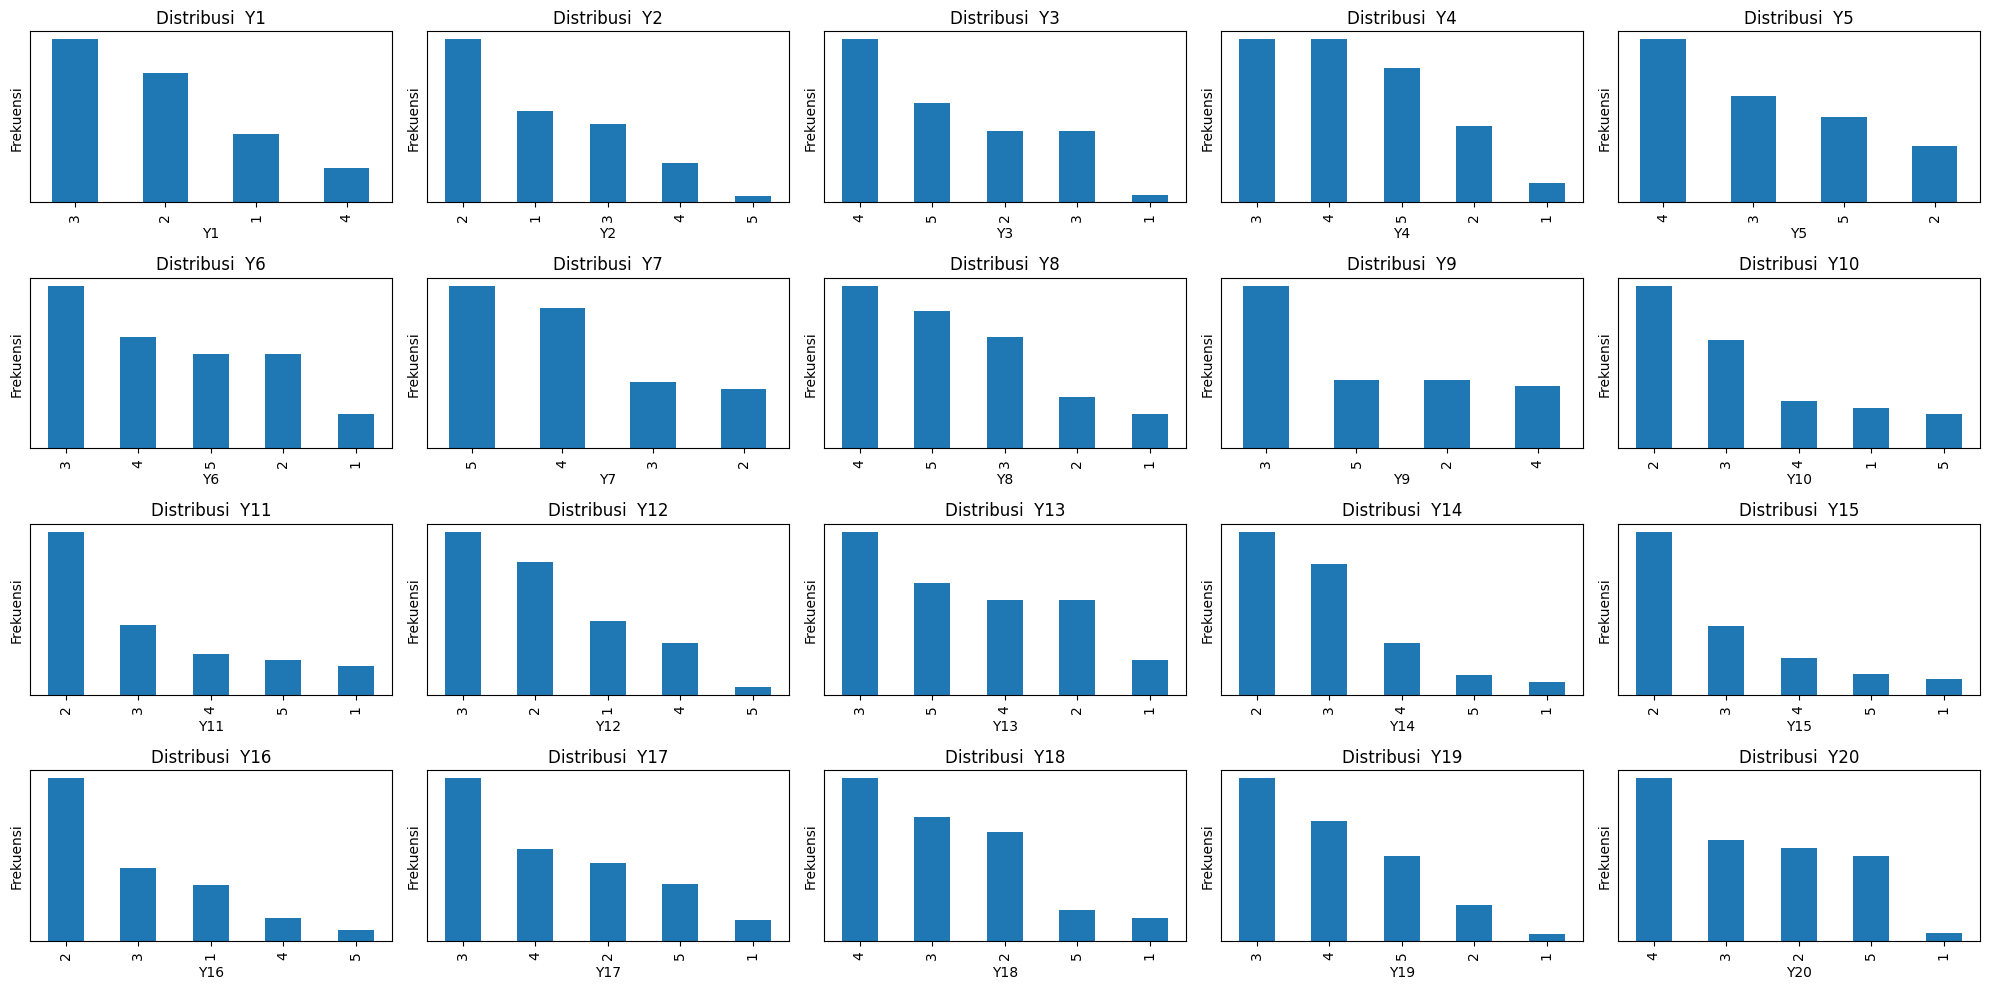

In [62]:
fig, ax = plt.subplots(4, 5, figsize=(20, 10))

ax = ax.flatten()

for i, col in enumerate(var_y.columns[:20]):
    var_y[col].value_counts().plot(kind = 'bar', ax = ax[i])
    ax[i].set_title(f'Distribusi  {col}')
    ax[i].set_xlabel(f'{col}')
    ax[i].set_ylabel('Frekuensi')
    ax[i].set_yticks([])
    
plt.tight_layout()
plt.show()

# Feature Engineering

In [63]:
var_y.head()

,Y1,Y2,Y3,Y4,Y5,Y6,Y7,Y8,Y9,Y10,Y11,Y12,Y13,Y14,Y15,Y16,Y17,Y18,Y19,Y20
0,2,5,5,5,4,5,5,5,5,3,3,2,5,4,4,2,5,4,3,5
1,2,2,4,3,4,2,4,4,4,3,4,4,4,2,2,2,5,4,5,5
2,3,2,5,4,2,3,4,5,3,3,4,4,4,3,3,2,3,3,3,2
3,2,3,4,4,3,3,4,2,2,3,5,4,3,4,4,2,3,3,4,3
4,1,1,2,3,3,3,4,3,3,4,2,2,2,3,3,2,1,4,4,1


In [64]:
var_y_scaled = MinMaxScaler().fit_transform(var_y)

In [65]:
var_y_scaled

array([[0.33333333, 1.        , 1.        , ..., 0.75      , 0.5       ,
        1.        ],
       [0.33333333, 0.25      , 0.75      , ..., 0.75      , 1.        ,
        1.        ],
       [0.66666667, 0.25      , 1.        , ..., 0.5       , 0.5       ,
        0.25      ],
       ...,
       [0.33333333, 0.25      , 1.        , ..., 1.        , 1.        ,
        1.        ],
       [0.        , 0.        , 0.75      , ..., 0.75      , 0.75      ,
        0.25      ],
       [0.66666667, 0.5       , 1.        , ..., 0.75      , 0.75      ,
        1.        ]])

# Modeling

## Regression

In [66]:
df['target'] = var_y.sum(axis = 1) / 20

In [67]:
df['target']

0     4.05
1     3.45
2     3.25
3     3.25
4     2.55
5     3.00
6     3.50
7     3.00
8     3.55
9     3.15
10    2.90
11    2.95
12    3.45
13    2.90
14    3.25
15    2.90
16    3.05
17    2.90
18    2.70
19    4.00
20    4.65
21    2.10
22    2.55
23    2.80
24    3.30
25    4.00
26    2.85
27    2.60
28    3.15
29    2.85
30    2.80
31    3.30
32    3.95
33    2.45
34    2.55
35    2.20
36    2.90
37    3.75
38    3.50
39    3.30
40    3.20
41    2.90
42    2.75
43    2.70
44    2.85
45    2.55
46    3.85
47    2.85
48    2.80
49    2.80
50    3.05
51    2.70
52    2.90
53    3.00
54    3.45
55    3.75
56    2.45
57    4.05
Name: target, dtype: float64

In [68]:
df['weight'] = df['Kelas'].map(weight)

In [69]:
x = df.drop(columns=['target'])
y = df['target']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.15  , random_state=SEED)

print(x_train.shape)
print(x_test.shape)

(49, 13)
(9, 13)


In [70]:
lr = LinearRegression()

ohe_col = ['Gender', 'Kelas']
other_col = x.drop(columns = ohe_col + ['weight']).columns

prep = ColumnTransformer([
    ('ohe', OneHotEncoder(), ohe_col),
    ('other', 'passthrough', other_col)
])

lr_pipeline = Pipeline([
    ('preprocessor', prep),
    ('lr', lr)
])

lr_pipeline.fit(x_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('ohe', OneHotEncoder(),
                                                  ['Gender', 'Kelas']),
                                                 ('other', 'passthrough',
                                                  Index(['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10'], dtype='object'))])),
                ('lr', LinearRegression())])

### Evaluasi Regression

In [71]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# prediksi
y_pred_train = lr_pipeline.predict(x_train)
y_pred_test = lr_pipeline.predict(x_test)

# train metrics
mae_train = mean_absolute_error(y_train, y_pred_train)
mse_train = mean_squared_error(y_train, y_pred_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
r2_train = r2_score(y_train, y_pred_train)

# test metrics
mae_test = mean_absolute_error(y_test, y_pred_test)
mse_test = mean_squared_error(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_test = r2_score(y_test, y_pred_test)

print("=== TRAIN ===")
print("MAE  :", mae_train)
print("MSE  :", mse_train)
print("RMSE :", rmse_train)
print("R2   :", r2_train)

print("\n=== TEST ===")
print("MAE  :", mae_test)
print("MSE  :", mse_test)
print("RMSE :", rmse_test)
print("R2   :", r2_test)

=== TRAIN ===
MAE  : 0.27394201187124373
MSE  : 0.14448753358515584
RMSE : 0.38011515832068027
R2   : 0.35126447038745

=== TEST ===
MAE  : 0.5164972638788118
MSE  : 0.3758862040706158
RMSE : 0.6130955912992816
R2   : 0.10595264925209569


### Interpretasi Model Regression

In [72]:
feature_names = lr_pipeline.named_steps['preprocessor'].get_feature_names_out()

coef = lr_pipeline.named_steps['lr'].coef_

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coef*100
})

coef_df.head(20)

,Feature,Coefficient
0,ohe__Gender_Pria,0.978725
1,ohe__Gender_Wanita,-0.978725
2,ohe__Kelas_LA09,13.850443
3,ohe__Kelas_LB09,5.119036
4,ohe__Kelas_LC09,-3.177392
5,ohe__Kelas_LD09,3.195639
6,ohe__Kelas_LE09,-18.987725
7,other__X1,35.016016
8,other__X2,-7.957348
9,other__X3,-5.904174


### Repair data

In [73]:
df = df.drop(columns='target')

In [74]:
df.columns

Index(['Kelas', 'Gender', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9',
       'X10', 'weight'],
      dtype='object')

## Clustering

In [75]:
kmeans_scaled = KMeans(n_clusters = 4, random_state=SEED)
kmeans_scaled.fit(var_y_scaled)

KMeans(n_clusters=4, random_state=1)

In [76]:
kmeans = KMeans(n_clusters = 4, random_state=SEED)
kmeans.fit(var_y)

KMeans(n_clusters=4, random_state=1)

In [77]:
pred = kmeans.predict(var_y)
pred_scaled = kmeans_scaled.predict(var_y_scaled)

In [78]:
temp = var_y.copy()

temp['target_raw'] = pred
temp['target_scaled'] = pred_scaled

temp.head()

,Y1,Y2,Y3,Y4,Y5,Y6,Y7,Y8,Y9,Y10,...,Y13,Y14,Y15,Y16,Y17,Y18,Y19,Y20,target_raw,target_scaled
0,2,5,5,5,4,5,5,5,5,3,...,5,4,4,2,5,4,3,5,2,2
1,2,2,4,3,4,2,4,4,4,3,...,4,2,2,2,5,4,5,5,2,2
2,3,2,5,4,2,3,4,5,3,3,...,4,3,3,2,3,3,3,2,2,1
3,2,3,4,4,3,3,4,2,2,3,...,3,4,4,2,3,3,4,3,2,2
4,1,1,2,3,3,3,4,3,3,4,...,2,3,3,2,1,4,4,1,3,3


In [79]:
# var_y.head()

In [80]:
raw = var_y.copy()

raw['result'] = pred

profile_raw = raw.groupby(['result']).mean()

profile_raw

,Y1,Y2,Y3,Y4,Y5,Y6,Y7,Y8,Y9,Y10,Y11,Y12,Y13,Y14,Y15,Y16,Y17,Y18,Y19,Y20
result,,,,,,,,,,,,,,,,,,,,
0,1.800000,1.800000,2.000000,3.800000,3.400000,4.600000,4.800000,3.800000,4.000000,4.000000,4.200000,2.000000,3.200000,3.000000,3.000000,2.400000,2.600000,2.400000,2.600000,2.400000
1,2.481481,2.259259,3.925926,3.370370,3.555556,2.444444,3.333333,3.148148,3.148148,2.222222,2.259259,2.629630,3.074074,2.333333,2.037037,2.111111,3.074074,3.000000,3.481481,3.555556
2,2.736842,2.526316,4.210526,4.315789,4.105263,3.894737,4.315789,4.263158,3.842105,3.315789,3.157895,2.842105,4.157895,3.473684,3.578947,2.578947,4.052632,3.684211,3.947368,4.263158
3,1.714286,1.571429,2.428571,2.142857,3.142857,3.857143,4.714286,3.714286,2.428571,1.714286,1.857143,1.428571,2.000000,2.142857,2.000000,2.142857,1.857143,2.857143,3.714286,2.000000


In [81]:
scaled = var_y.copy()

scaled['result'] = pred_scaled

profile_scaled = scaled.groupby(['result']).mean()

profile_scaled

,Y1,Y2,Y3,Y4,Y5,Y6,Y7,Y8,Y9,Y10,Y11,Y12,Y13,Y14,Y15,Y16,Y17,Y18,Y19,Y20
result,,,,,,,,,,,,,,,,,,,,
0,2.400000,2.200000,2.600000,4.800000,4.2,4.400000,4.800000,5.000000,4.800000,4.200000,4.400000,3.000000,4.200000,3.200000,3.200000,2.800000,3.400000,3.200000,3.200000,3.200000
1,2.833333,2.444444,4.000000,3.500000,3.5,2.444444,2.888889,3.500000,2.944444,2.055556,2.000000,2.833333,2.888889,2.388889,2.111111,2.222222,3.111111,3.388889,3.277778,3.777778
2,2.450000,2.300000,4.350000,4.250000,4.2,3.800000,4.150000,3.850000,3.850000,2.850000,2.950000,2.500000,4.150000,3.150000,3.150000,2.350000,4.050000,3.500000,4.000000,4.050000
3,1.866667,1.866667,2.733333,2.333333,3.0,3.200000,4.666667,3.066667,2.733333,2.666667,2.533333,1.933333,2.400000,2.466667,2.333333,2.133333,2.133333,2.400000,3.533333,2.533333


In [82]:
y_cols = var_y.columns.tolist()

In [83]:
mean_pre_cluster_raw = temp.groupby('target_raw')[y_cols].mean().mean(axis=1)
stress_map_raw = mean_pre_cluster_raw.rank().astype(int).to_dict()

temp['stress_level_raw'] = temp['target_raw'].map(stress_map_raw)

print("Variabel Y Raw")
pd.DataFrame({
    'mean': mean_pre_cluster_raw,
    'stress_level_raw': stress_map_raw
}).sort_values('stress_level_raw')

Variabel Y Raw


,mean,stress_level_raw
3,2.471429,1
1,2.872222,2
0,3.090000,3
2,3.663158,4


In [84]:
mean_pre_cluster_scaled = temp.groupby('target_scaled')[y_cols].mean().mean(axis = 1)
stress_map_scaled = mean_pre_cluster_scaled.rank().astype(int).to_dict()

temp['stress_level_scaled'] = temp['target_scaled'].map(stress_map_scaled)

print("Variabel Y Scaled")
pd.DataFrame({
    'mean': mean_pre_cluster_scaled,
    'stress_level_scaled': stress_map_scaled
}).sort_values('stress_level_scaled')

Variabel Y Scaled


,mean,stress_level_scaled
3,2.626667,1
1,2.905556,2
2,3.495000,3
0,3.660000,4


### Evaluasi Model Clustering

In [85]:
print("Clustering Variabel Y Raw")
print("="*45)
print("Silhouette Score:", silhouette_score(var_y, pred))
print("Davies Bouldin Score:", davies_bouldin_score(var_y, pred))
print("Calinski Harabasz Score:", calinski_harabasz_score(var_y, pred))

print("="*45, "\n")

print("CLustering Variabel Y Scaled")
print("="*45)
print("Silhouette Score:", silhouette_score(var_y_scaled, pred_scaled))
print("Davies Bouldin Score:", davies_bouldin_score(var_y_scaled, pred_scaled))
print("Calinski Harabasz Score:", calinski_harabasz_score(var_y_scaled, pred_scaled))
print("="*45)

Clustering Variabel Y Raw
Silhouette Score: 0.12807374115034412
Davies Bouldin Score: 1.8480970705502076
Calinski Harabasz Score: 7.9427847183903655

CLustering Variabel Y Scaled
Silhouette Score: 0.09715353474171907
Davies Bouldin Score: 2.128540801456246
Calinski Harabasz Score: 7.824793853247932


In [86]:
# Sudah ada di notebookmu, tinggal rapikan:
results = {}
for k in range(2, 5):
    km = KMeans(n_clusters=k, random_state=SEED)
    labels = km.fit_predict(var_y)
    
    results[k] = {
        'silhouette': silhouette_score(var_y, labels),   # makin tinggi makin baik (max 1)
        'dbi':        davies_bouldin_score(var_y, labels), # makin rendah makin baik
        'ch':         calinski_harabasz_score(var_y, labels) # makin tinggi makin baik
    }

pd.DataFrame(results).T

,silhouette,dbi,ch
2,0.170055,1.856786,12.507664
3,0.140975,1.860590,8.314254
4,0.128074,1.848097,7.942785


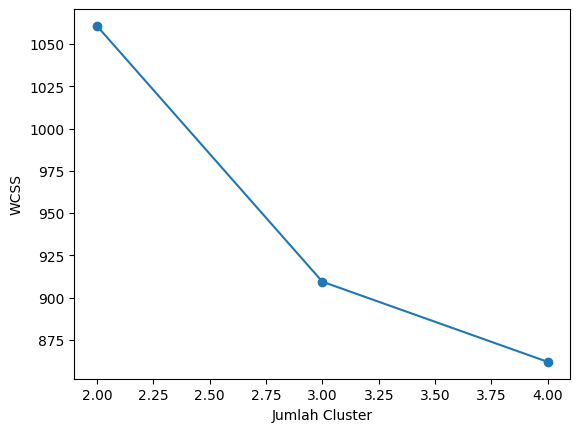

In [87]:
wcss = []

for k in range(2,5):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(var_y)
    wcss.append(km.inertia_)

plt.plot(range(2,5), wcss, marker='o')
plt.xlabel('Jumlah Cluster')
plt.ylabel('WCSS')
plt.show()

## Data Setup

In [88]:
temp.head()

,Y1,Y2,Y3,Y4,Y5,Y6,Y7,Y8,Y9,Y10,...,Y15,Y16,Y17,Y18,Y19,Y20,target_raw,target_scaled,stress_level_raw,stress_level_scaled
0,2,5,5,5,4,5,5,5,5,3,...,4,2,5,4,3,5,2,2,4,3
1,2,2,4,3,4,2,4,4,4,3,...,2,2,5,4,5,5,2,2,4,3
2,3,2,5,4,2,3,4,5,3,3,...,3,2,3,3,3,2,2,1,4,2
3,2,3,4,4,3,3,4,2,2,3,...,4,2,3,3,4,3,2,2,4,3
4,1,1,2,3,3,3,4,3,3,4,...,3,2,1,4,4,1,3,3,1,1


In [89]:
df['target'] = temp['stress_level_scaled']

In [90]:
df.head()

,Kelas,Gender,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,weight,target
0,LC09,Pria,3,3,2,2,3,3,2,3,2,2,0.9261,3
1,LA09,Wanita,3,2,2,2,2,3,2,2,2,2,0.8435,3
2,LB09,Pria,4,3,3,2,2,4,3,3,3,2,0.5788,2
3,LB09,Pria,3,3,3,2,3,4,3,4,3,4,0.5788,3
4,LB09,Wanita,3,3,2,2,3,3,3,3,3,3,0.5788,1


## Classification

In [91]:
weights = df['weight']

df = df.drop('weight', axis = 1)

x = df.drop('target', axis = 1)
y = df['target']

x_train, x_test, y_train, y_test, w_train, w_test = train_test_split(x, y, weights, test_size=0.2, stratify=y, random_state=SEED)

print(x_train.shape)
print(y_train.shape)

print(x_test.shape)
print(y_test.shape)

print(y_train.value_counts())
print(y_test.value_counts())

(46, 12)
(46,)
(12, 12)
(12,)
target
3    16
2    14
1    12
4     4
Name: count, dtype: int64
target
3    4
2    4
1    3
4    1
Name: count, dtype: int64


In [92]:
m_logit = LogisticRegression(multi_class='multinomial', max_iter = 1000, penalty=None)

model = Pipeline([
    ('prep', prep),
    ('logit', m_logit)
])

model.fit(x_train, y_train, logit__sample_weight=w_train)

c:\Users\willi\anaconda3\envs\stats-env\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('ohe', OneHotEncoder(),
                                                  ['Gender', 'Kelas']),
                                                 ('other', 'passthrough',
                                                  Index(['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10'], dtype='object'))])),
                ('logit',
                 LogisticRegression(max_iter=1000, multi_class='multinomial',
                                    penalty=None))])

In [93]:
y_pred = model.predict(x_test)

In [94]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       1.00      0.33      0.50         3
           2       0.60      0.75      0.67         4
           3       0.75      0.75      0.75         4
           4       0.00      0.00      0.00         1

    accuracy                           0.58        12
   macro avg       0.59      0.46      0.48        12
weighted avg       0.70      0.58      0.60        12



In [95]:
feature_names = model.named_steps['prep'].get_feature_names_out()

coef = model.named_steps['logit'].coef_

classes = model.named_steps['logit'].classes_

coef_df = pd.DataFrame(
    coef.T,
    columns=[f'{c}' for c in classes],
    index = feature_names
)

coef_df.head(20)

,1,2,3,4
ohe__Gender_Pria,-1.786998,3.417355,6.474835,-8.105192
ohe__Gender_Wanita,-4.630739,-4.745528,0.143507,9.232760
ohe__Kelas_LA09,-9.168236,-5.932100,-2.114706,17.215042
ohe__Kelas_LB09,-3.684693,-1.838600,3.029333,2.493959
ohe__Kelas_LC09,3.050696,4.457112,10.060027,-17.567835
ohe__Kelas_LD09,-2.854503,-6.378108,6.995134,2.237477
ohe__Kelas_LE09,6.238999,8.363523,-11.351447,-3.251076
other__X1,-1.368756,1.364493,4.230809,-4.226546
other__X2,3.124410,0.438893,3.349937,-6.913240
other__X3,-0.253689,1.270841,-2.147814,1.130661
